In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

from pathlib import Path

def _abs_parquet(rel):
    """Resolve a path relative to src/notebooks and return the absolute parquet path."""
    here = Path.cwd().resolve()
    data = None
    for candidate in (here, *here.parents):
        if (candidate / 'src' / 'data').is_dir() and (candidate / 'src' / 'notebooks').is_dir():
            data = candidate / 'src' / 'data'
            break
        if candidate.name == 'notebooks' and (candidate.parent / 'data').is_dir():
            data = (candidate.parent / 'data').resolve()
            break
    if data is None:
        raise FileNotFoundError(f'Could not locate src/data from {here}')
    path = (data / rel.removeprefix('../data/')).resolve()
    matches = list(path.parent.glob(path.name)) if '*' in path.name else ([path] if path.is_file() else [])
    if not matches:
        raise FileNotFoundError(path)
    return str(path)

repos_path = _abs_parquet('../data/gitskills_data/data/repos/*.parquet')
artifacts_path = _abs_parquet('../data/gitskills_data/data/artifacts/*.parquet')
artifact_siblings_path = _abs_parquet('../data/gitskills_data/data/artifact_siblings/*.parquet')
mining_runs_path = _abs_parquet('../data/gitskills_data/data/mining_runs/*.parquet')
skill_features_path = _abs_parquet('../data/generated_data/skill_features.parquet')
file_agents_path = _abs_parquet('../data/generated_data/file_agents.parquet')

con = duckdb.connect(database=':memory:')

## Skill names

Front-matter names are not identity: the same name is reused by different skill texts.


In [ ]:
file_frequency = con.execute(f"""
    SELECT COUNT(*) AS SHARED_NAMES,  SUM(n) AS SKILLS_INVOLVED
    FROM (SELECT lower(name) AS nm, COUNT(*) AS n
      FROM read_parquet('{artifacts_path}')
      WHERE dedup_primary = 1 AND name <> ''
      GROUP BY nm
      HAVING n > 1)
""").df().astype(int)
file_frequency

,SHARED_NAMES,SKILLS_INVOLVED
0,162855,950937


## Names are not identity

**Question:** Can a skill's front-matter `name` identify the same skill across
repositories?

**Method:** Among distinct skills (`dedup_primary = 1`, so every row is a
different text), group by lowercase `name` and count how many different texts
share each name.

**Findings (full dataset)**
- 162,855 names are each used by two or more different skills.
- Together they cover 950,937 distinct skills, about half (50.6%) of all
  1,877,981 distinct skills.
- On average, a shared name is attached to about 5.8 different texts.
- The most shared names are generic verbs and tasks (in the sample: `code-review`
  with 37 different texts, `commit`, `plan`, `review`, `debug`), alongside
  names of widely copied skills such as `skill-creator`, whose many variants
  are likely edited versions of one source.

**Why it happens**
- *Name collisions:* unrelated skills independently pick the same generic name.
- *Edited copies:* one skill is copied and modified, so the text (and hash)
  changes but the name stays.
- The reverse also occurs: template families produce near-identical skills with
  different names (see the near-duplicate section).

**Implication:** A shared name is not evidence of shared content, and a
different name is not evidence of different content. We identify exact copies
by `file_sha` and related versions by text similarity; `name` is used only as a
label.

**Caveats**
- Names are compared after lowercasing only; `code_review` and `code-review`
  count as different names, so collisions are, if anything, understated.
- Skills with empty names are excluded.

In [8]:
skill_names_reused = con.execute(f"""
    SELECT lower(name) AS nm, COUNT(*) AS n
      FROM read_parquet('{artifacts_path}')
      WHERE dedup_primary = 1 AND name <> ''
      GROUP BY nm
      ORDER BY n DESC;
""").df()
skill_names_reused

,nm,n
0,code-review,3690
1,skill-creator,2765
2,commit,2461
3,review,2208
4,frontend-design,2161
...,...,...
845416,open-source-intel,1
845417,astronautenrettung-rueckgabe-und-statusfragen,1
845418,reply-learning,1
845419,node-code-style,1


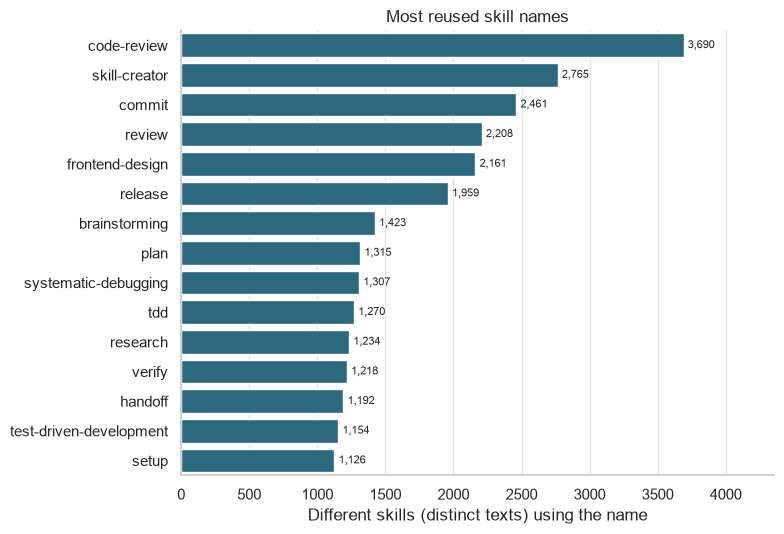

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
hbar(skill_names_reused.head(15), "nm", "n", ax)
ax.set_xlabel("Different skills (distinct texts) using the name")
ax.set_title("Most reused skill names")
plt.tight_layout(); plt.show()

## Most reused skill names

**Question:** Which front-matter names are used by the most *different* skills?

**Method:** Among distinct skills (`dedup_primary = 1`, one row per unique
text), group by lowercase `name` and count the distinct texts per name.

**Findings (full dataset)**

| Name | Distinct skills using it |
|---|---|
| code-review | 3,690 |
| skill-creator | 2,765 |
| commit | 2,461 |
| review | 2,208 |
| frontend-design | 2,161 |
| release | 1,959 |
| brainstorming | 1,423 |
| plan | 1,315 |
| systematic-debugging | 1,307 |
| tdd | 1,270 |

The top names fall into two groups that reflect different mechanisms:

- **Generic task names** (`code-review`, `commit`, `review`, `release`, `plan`,
  `tdd`). These describe common development tasks, so unrelated authors
  likely arrive at the same name independently: *name collisions*.
- **Names of well-known published skills** (`skill-creator`, `frontend-design`,
  `brainstorming`, `systematic-debugging`). These come from widely promoted
  sources (Anthropic's official skills and the Superpowers collection), so their
  many texts are likely *edited versions of one original*.

The second group connects to adoption: the single most-adopted
`frontend-design` text appears in 897 owners' repositories, yet 2,161 different
texts carry that name. Counting one exact text understates how far a popular
skill has spread.

**Implication:** For generic names, a shared name says little about shared
content. For names of published skills, it often marks a family of edited
versions, which text similarity (not hashing) is needed to group.

**Caveats**
- Collision vs edited-version is inferred from the name type, not measured;
  the near-duplicate analysis tests it directly.
- Names are compared after lowercasing only, so variants such as `code_review`
  or `code-reviewer` are counted separately.

#### One name family: `skill-creator`

Same front-matter name, different texts. Similar lengths and descriptions suggest edited copies; a wide spread suggests the name is a collision, not an identity.


In [1]:
creator = con.execute(f"""
SELECT file_sha, repo_full_name, body_chars,
       substr(coalesce(description, ''), 1, 100) AS description
FROM read_parquet('{artifacts_path}')
WHERE dedup_primary = 1 AND lower(name) = 'skill-creator'
ORDER BY body_chars
""").df()
print(f"{len(creator):,} distinct contents use the name skill-creator")
print("body_chars percentiles:", creator.body_chars.quantile([.1, .25, .5, .75, .9]).round(0).to_dict())
pd.concat([creator.head(8), creator.tail(8)])


2,765 distinct contents use the name skill-creator
body_chars percentiles: {0.1: 2215.0, 0.25: 4775.0, 0.5: 12581.0, 0.75: 18743.0, 0.9: 32627.0}


,file_sha,repo_full_name,body_chars,description
0,9491860cbe2fd39656051f0adecbe68d9222a091,lightspeedwp/.github,1,"Guide for creating and updating high-quality skills by translating workflows, conventions, and reusa"
1,8eb9eb1497985bb0741d1c4ad807ae3246063cbf,alvarosanchez/micronaut-agent-company,1,Reference the upstream Micronaut project-template skill for creating and refining portable agent ski
2,86cbb61356b6c9f7c6e03211eb1ce669b4925daf,ssiumha/dots,33,"Creates and manages Claude Code skills. Use when creating new skills, updating existing skills, or c"
3,93c86a8bc46ff8ed28c804fcf7a71cee3ee2f5d8,I-Synergy/AI,43,"Create new skills, modify and improve existing skills, and measure skill performance. Use when users"
4,bac812279b7c36404149053a291753aca61fb1d9,shinytoyrobots/claude-skills-linter,61,Create new skills
5,c5f3d16c91696fbc504307d8ad8ed91d402a3883,ywatanabe1989/scitex-dev,63,"ALWAYS invoke this skill when the user creates, edits, optimizes, benchmarks, or evaluates a Claude"
6,5ec6a8bb76b6ebcb076758b1a5af23cf708c9aac,mombe090/.files,93,Guide for creating effective skills. This skill should be used when users want to create a new skill
7,bebae553ff894169a1fbfc6679aae8e805734fbc,diegocanepa/agent-skills,100,Helper to install the official skill creator from skills.sh
2757,eb68259abe338d5b2c0a879026053e63e5ad7baf,okw0204/dotfiles,62258,"Create new skills, modify and improve existing skills, and measure skill performance. Use when users"
2758,6fbf5e5503827412f992d57b9f48454c6c743c8d,791994545/Deepseek-Reasonix-Autopilot,65063,"Create new skills, modify and improve existing skills, and measure skill performance. Use when users"


`skill-creator` is 2,765 distinct contents, not one text. Body length runs from 1 characters to 114,417 (10th percentile 2,215, median 12,581, 90th 32,627). The short end is stubs that point at another skill; the long end is a full authoring guide. The shared name covers both collisions and a template family.
